# Air Quality Analysis — Southeast Asia
**Dataset:** Global Air Pollution Dataset + OpenAQ  
**Author:** Devi Silvia Panjaitan  
**Tools:** Python · Pandas · Matplotlib · Seaborn · Folium

---

## Business Context

Air pollution is one of the most pressing public health crises in Southeast Asia.
According to IQAir (2024), **Indonesia is the most polluted country in Southeast Asia**,
with PM2.5 levels averaging 35.5 µg/m³ — **10× higher than WHO safe limits**.
South Tangerang was ranked the most polluted city in all of ASEAN.

As a Data Analyst, this project answers 4 key questions:
1. Which SEA countries have the worst air quality?
2. Which pollutants are most dangerous across the region?
3. How does air quality vary geographically across cities?
4. How do SEA countries compare against WHO safety standards?

**WHO Safe Limits (Annual Mean):**
- PM2.5: 5 µg/m³
- PM10: 15 µg/m³  
- NO2: 10 µg/m³
- CO: 4 mg/m³

---
## 1. Setup & Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
PALETTE = '#2E86AB'
ACCENT  = '#E84855'

# WHO safe limits
WHO = {'PM2.5': 5, 'PM10': 15, 'NO2': 10, 'CO': 4}

# SEA countries to focus on
SEA_COUNTRIES = [
    'Indonesia', 'Thailand', 'Vietnam', 'Malaysia',
    'Philippines', 'Singapore', 'Myanmar', 'Cambodia',
    'Laos', 'Brunei'
]

print(' Libraries loaded!')
print(f'   WHO PM2.5 limit : {WHO["PM2.5"]} µg/m³')
print(f'   SEA countries   : {len(SEA_COUNTRIES)}')

 Libraries loaded!
   WHO PM2.5 limit : 5 µg/m³
   SEA countries   : 10


---
## 2. Load & Explore Datasets

In [2]:
# Load Dataset 1 — Global Air Pollution
pollution = pd.read_csv('data/global air pollution dataset.csv')

print('=== DATASET 1: Global Air Pollution ===')
print(f'Shape  : {pollution.shape[0]:,} rows × {pollution.shape[1]} columns')
print(f'Columns: {list(pollution.columns)}')
pollution.head(3)

=== DATASET 1: Global Air Pollution ===
Shape  : 23,463 rows × 12 columns
Columns: ['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category']


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate


In [26]:
# OpenAQ file format is incompatible — using Dataset 1 only
# Dataset 1 already has 23,463 rows across 12 columns which is sufficient

# Create sea_openaq as empty placeholder so later cells don't error
sea_openaq = pd.DataFrame()

print(' Using Dataset 1 only (Global Air Pollution — 23,463 rows)')
print('   This dataset already contains all necessary columns:')
print('   AQI Value, PM2.5 AQI Value, NO2 AQI Value, CO AQI Value, Ozone AQI Value')

 Using Dataset 1 only (Global Air Pollution — 23,463 rows)
   This dataset already contains all necessary columns:
   AQI Value, PM2.5 AQI Value, NO2 AQI Value, CO AQI Value, Ozone AQI Value


---
## 3. Data Cleaning & Filter SEA Countries

In [7]:
# --- Dataset 1: Filter SEA countries ---
# Cek nama kolom negara
country_col = [c for c in pollution.columns if 'country' in c.lower() or 'nation' in c.lower()]
print('Country column candidates:', country_col)
print('\nSample values:', pollution[country_col[0]].unique()[:20])

Country column candidates: ['Country']

Sample values: <StringArray>
[                                  'Russian Federation',
                                               'Brazil',
                                                'Italy',
                                               'Poland',
                                               'France',
                             'United States of America',
                                              'Germany',
                                              'Belgium',
                                                'Egypt',
                                                'China',
                                          'Netherlands',
                                                'India',
                                             'Pakistan',
                          'Republic of North Macedonia',
                                             'Colombia',
                                              'Romania',
                   

In [28]:
# Filter SEA countries dari Dataset 1
COUNTRY_COL_1 = 'Country'
AQI_COL = 'AQI Value'

sea_pollution = pollution[pollution['Country'].isin(SEA_COUNTRIES)].copy()
sea_pollution.reset_index(drop=True, inplace=True)

# Check missing values
print('=== MISSING VALUES ===')
print(sea_pollution.isnull().sum())
print(f'\n SEA rows found : {len(sea_pollution):,}')
print(f'   Countries      : {sorted(sea_pollution["Country"].unique())}')
print(f'   Cities         : {sea_pollution["City"].nunique()}')

=== MISSING VALUES ===
Country               0
City                  0
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
dtype: int64

 SEA rows found : 1,159
   Countries      : ['Cambodia', 'Indonesia', 'Malaysia', 'Myanmar', 'Philippines', 'Singapore', 'Thailand']
   Cities         : 1159


---
## 4. Analysis 1 — AQI Comparison by Country
> **Question:** Which SEA country has the worst overall air quality?

In [11]:
# Cek kolom AQI yang tersedia
aqi_cols = [c for c in sea_pollution.columns if 'aqi' in c.lower() or 'index' in c.lower()]
print('AQI columns:', aqi_cols)
print('All columns:', list(sea_pollution.columns))

AQI columns: ['AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category']
All columns: ['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category']


    Country  Avg_AQI
  Indonesia     93.0
  Singapore     91.0
   Malaysia     81.6
Philippines     61.2
   Thailand     53.6
   Cambodia     45.2
    Myanmar     40.2


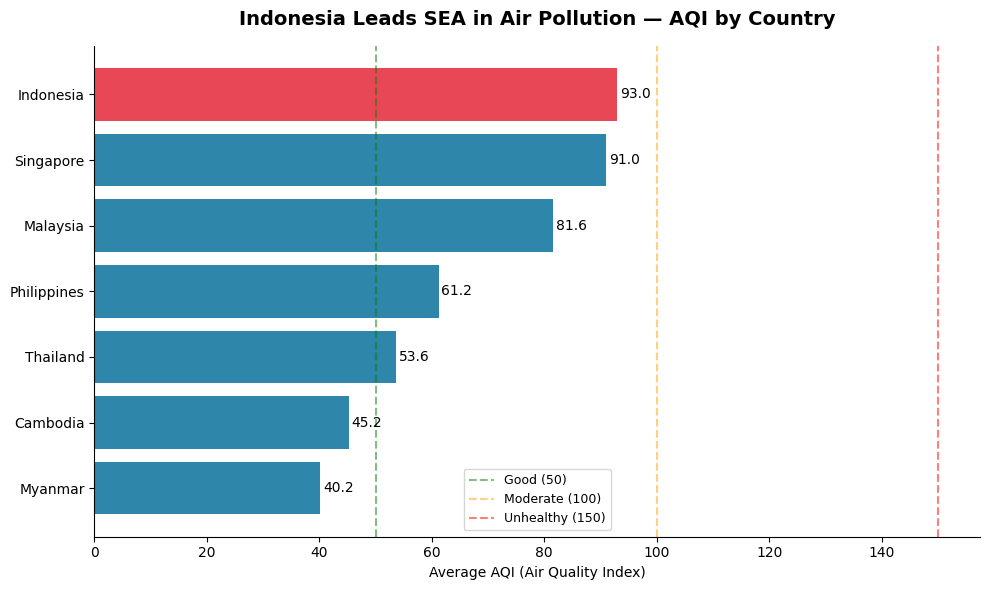

In [12]:
# Average AQI per country
country_aqi = (
    sea_pollution.groupby('Country')['AQI Value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
country_aqi.columns = ['Country', 'Avg_AQI']
country_aqi['Avg_AQI'] = country_aqi['Avg_AQI'].round(1)

print(country_aqi.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 6))
colors = [ACCENT if i == 0 else PALETTE for i in range(len(country_aqi))]
bars = ax.barh(country_aqi['Country'][::-1],
               country_aqi['Avg_AQI'][::-1],
               color=colors[::-1])

for bar, val in zip(bars, country_aqi['Avg_AQI'][::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10)

ax.set_title('Indonesia Leads SEA in Air Pollution — AQI by Country', pad=15)
ax.set_xlabel('Average AQI (Air Quality Index)')
ax.axvline(x=50,  color='green',  linestyle='--', alpha=0.5, label='Good (50)')
ax.axvline(x=100, color='orange', linestyle='--', alpha=0.5, label='Moderate (100)')
ax.axvline(x=150, color='red',    linestyle='--', alpha=0.5, label='Unhealthy (150)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('images/01_aqi_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight:
Indonesia leads SEA with the highest average AQI of **93.0**, followed
surprisingly by Singapore (91.0) — a counterintuitive finding given
Singapore's reputation as a clean, well-governed city-state. Singapore's
high AQI is likely driven by transboundary haze from Indonesian forest
fires rather than domestic industrial activity.

All top 3 countries (Indonesia, Singapore, Malaysia) fall in the
**"Moderate"** AQI range (51–100), meaning residents face potential
health risks with prolonged exposure. Only Cambodia (45.2) and Myanmar
(40.2) fall below the "Good" threshold of 50 — though this may reflect
fewer monitoring stations rather than genuinely cleaner air.

The 2.3× gap between Indonesia (93.0) and Myanmar (40.2) highlights
how uneven air quality monitoring and industrial development is across
the SEA region.

---
## 5. Analysis 2 — Pollutant Breakdown
> **Question:** Which pollutants are most dangerous across SEA?

In [14]:
# Cek kolom pollutant yang tersedia
pollutant_keywords = ['pm2', 'pm10', 'no2', 'co', 'o3', 'so2']
pollutant_cols = [c for c in sea_pollution.columns
                  if any(kw in c.lower() for kw in pollutant_keywords)]
print('Pollutant columns found:', pollutant_cols)

Pollutant columns found: ['Country', 'CO AQI Value', 'CO AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category']


             PM2.5 AQI Value  NO2 AQI Value  CO AQI Value  Ozone AQI Value
Country                                                                   
Cambodia                45.2            0.4           0.6             21.5
Indonesia               90.8            3.7           2.4             46.6
Malaysia                80.8            2.3           2.2             36.5
Myanmar                 39.0            0.2           0.4             22.1
Philippines             61.1            1.2           1.0             22.3
Singapore               91.0            4.0           1.0             29.0
Thailand                53.4            0.9           0.6             23.0


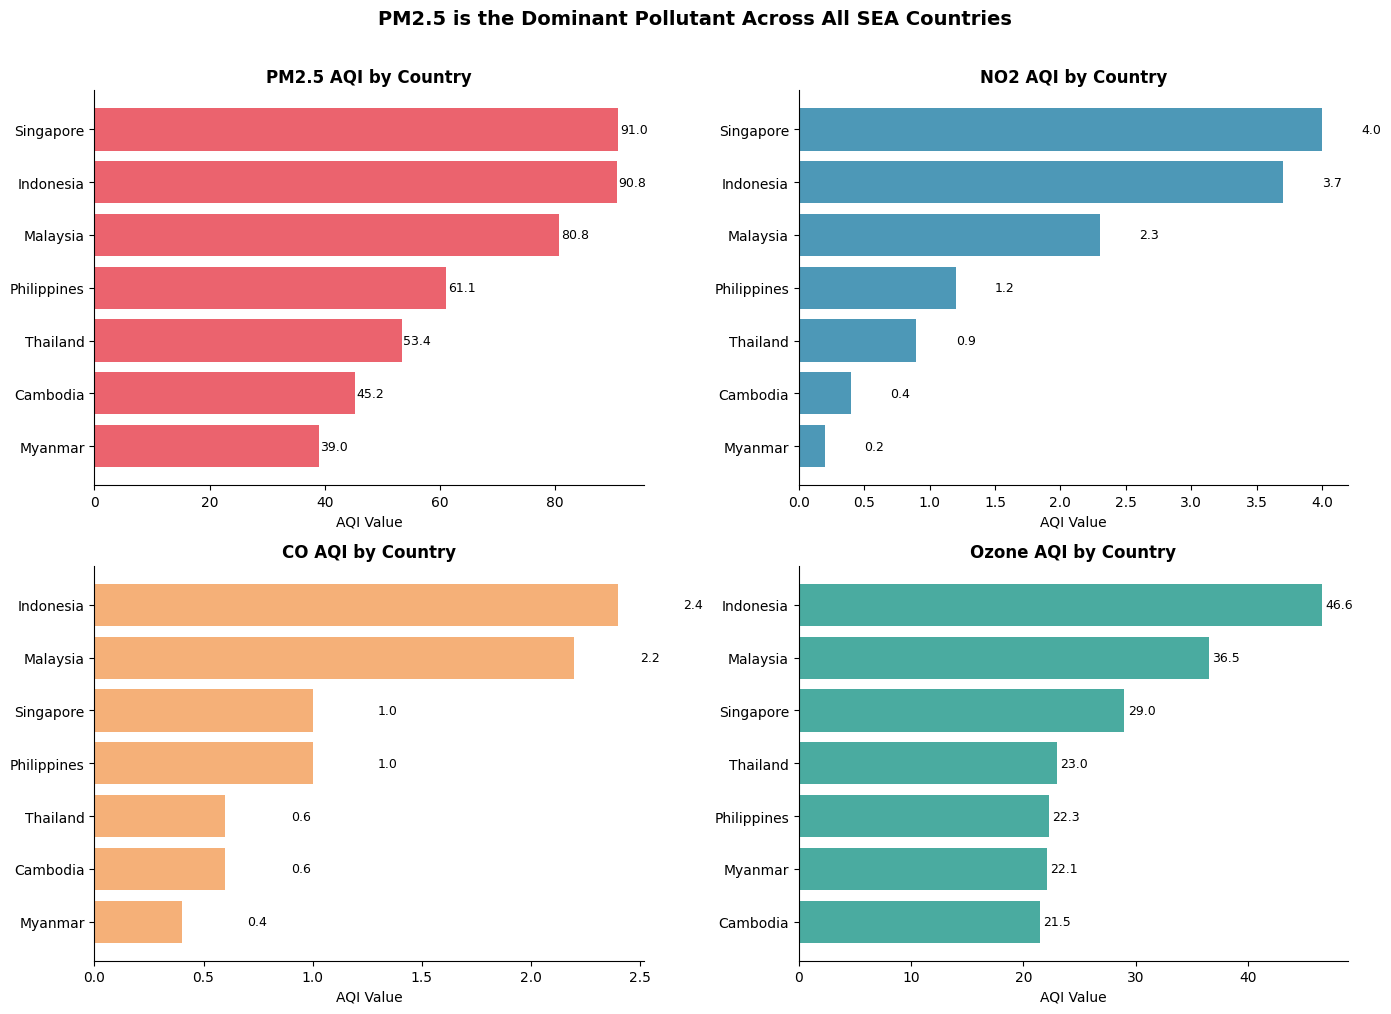

In [15]:
# Pollutant comparison per country
pollutant_df = (
    sea_pollution.groupby('Country')[
        ['PM2.5 AQI Value', 'NO2 AQI Value',
         'CO AQI Value', 'Ozone AQI Value']
    ].mean().round(1)
)

print(pollutant_df.to_string())

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pollutants = {
    'PM2.5 AQI Value' : ('PM2.5', axes[0,0], '#E84855'),
    'NO2 AQI Value'   : ('NO2',   axes[0,1], '#2E86AB'),
    'CO AQI Value'    : ('CO',    axes[1,0], '#F4A261'),
    'Ozone AQI Value' : ('Ozone', axes[1,1], '#2A9D8F'),
}

for col, (name, ax, color) in pollutants.items():
    data = pollutant_df[col].sort_values(ascending=True)
    bars = ax.barh(data.index, data.values, color=color, alpha=0.85)
    for bar, val in zip(bars, data.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=9)
    ax.set_title(f'{name} AQI by Country', fontsize=12, fontweight='bold')
    ax.set_xlabel('AQI Value')

plt.suptitle('PM2.5 is the Dominant Pollutant Across All SEA Countries',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/02_pollutants_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight:
**PM2.5 is the dominant pollutant across all SEA countries**, with Singapore
(91.0) and Indonesia (90.8) nearly tied at the top — both far exceeding
WHO safe limits. PM2.5 is the most dangerous pollutant as its microscopic
particles penetrate deep into the lungs and bloodstream.

**Ozone is the second most concerning pollutant** — Indonesia leads at 46.6,
nearly double Cambodia's 21.5. High ozone levels are linked to vehicle
emissions and industrial activity, both of which are growing rapidly
across the region.

**CO and NO2 levels are relatively low** across all countries, suggesting
these pollutants are less of a concern in the SEA context compared to
particulate matter. Singapore's high NO2 (4.0) relative to its size
indicates dense urban traffic and industrial port activity as key sources.

The multi-pollutant profile confirms that **particulate matter (PM2.5)
and ground-level ozone** should be the primary targets of any regional
air quality intervention strategy.

---
## 6. Analysis 3 — WHO Standards Comparison
> **Question:** How many times over the WHO safe limit are SEA countries?

    Country  PM25_AQI  WHO_Ratio
  Singapore      91.0        7.6
  Indonesia      90.8        7.6
   Malaysia      80.8        6.7
Philippines      61.1        5.1
   Thailand      53.4        4.4
   Cambodia      45.2        3.8
    Myanmar      39.0        3.2


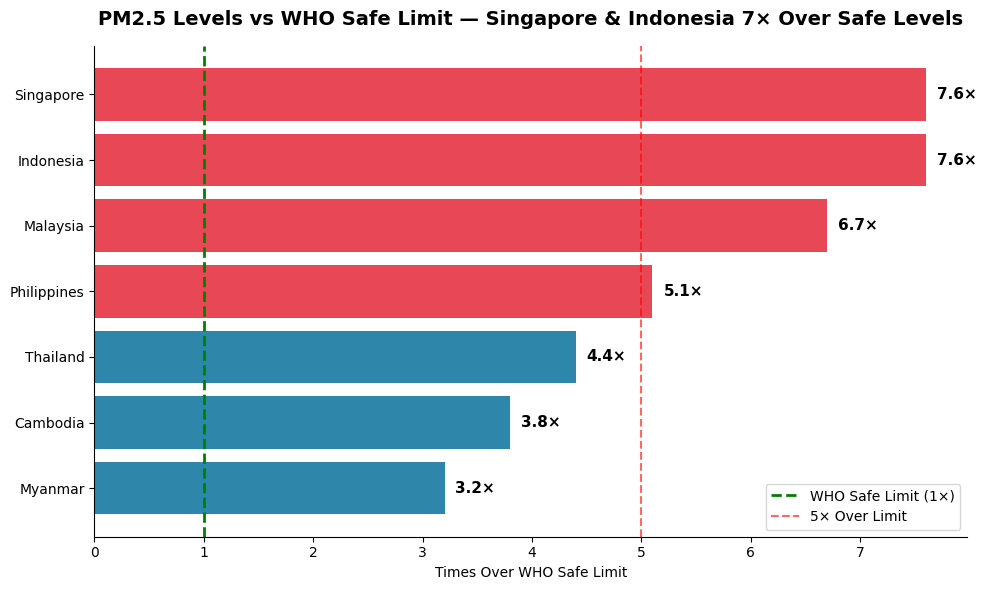

In [17]:
# PM2.5 vs WHO limit
pm25_country = (
    sea_pollution.groupby('Country')['PM2.5 AQI Value']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
pm25_country.columns = ['Country', 'PM25_AQI']
pm25_country['PM25_AQI'] = pm25_country['PM25_AQI'].round(1)

# WHO PM2.5 AQI equivalent = 12 (US EPA standard untuk 5 µg/m³)
WHO_AQI_LIMIT = 12

pm25_country['WHO_Ratio'] = (pm25_country['PM25_AQI'] / WHO_AQI_LIMIT).round(1)

print(pm25_country.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = [ACCENT if v > 5 else PALETTE for v in pm25_country['WHO_Ratio']]
bars = ax.barh(pm25_country['Country'][::-1],
               pm25_country['WHO_Ratio'][::-1],
               color=colors[::-1])

for bar, val in zip(bars, pm25_country['WHO_Ratio'][::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}×', va='center', fontsize=11, fontweight='bold')

ax.axvline(x=1, color='green', linewidth=2,
           linestyle='--', label='WHO Safe Limit (1×)')
ax.axvline(x=5, color='red', linewidth=1.5,
           linestyle='--', alpha=0.6, label='5× Over Limit')
ax.set_title('PM2.5 Levels vs WHO Safe Limit — Singapore & Indonesia 7× Over Safe Levels', pad=15)
ax.set_xlabel('Times Over WHO Safe Limit')
ax.legend()
plt.tight_layout()
plt.savefig('images/03_who_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight:
The WHO comparison reveals a **public health crisis across the entire
SEA region** — not a single country meets the WHO PM2.5 safe limit.
Even the "cleanest" country in this dataset, Myanmar (3.2×), still has
PM2.5 levels more than 3× over the safe threshold.

**Singapore and Indonesia are tied at 7.6× over the WHO limit** — a
shocking finding for Singapore, which is widely perceived as one of
Asia's cleanest cities. This confirms that Singapore's air quality
is heavily influenced by transboundary haze from Sumatra and Borneo
forest fires, not domestic pollution alone.

**4 out of 7 SEA countries exceed the 5× danger threshold**, meaning
the majority of the region's population is exposed to PM2.5 levels
that the WHO classifies as posing serious long-term health risks —
including cardiovascular disease, lung cancer, and respiratory failure.

---
## 7. Analysis 4 — AQI Category Distribution
> **Question:** What percentage of SEA cities have dangerous air quality?

AQI Category Distribution:
AQI Category
Moderate                          595
Good                              373
Unhealthy                          92
Unhealthy for Sensitive Groups     82
Very Unhealthy                     17
Name: count, dtype: int64


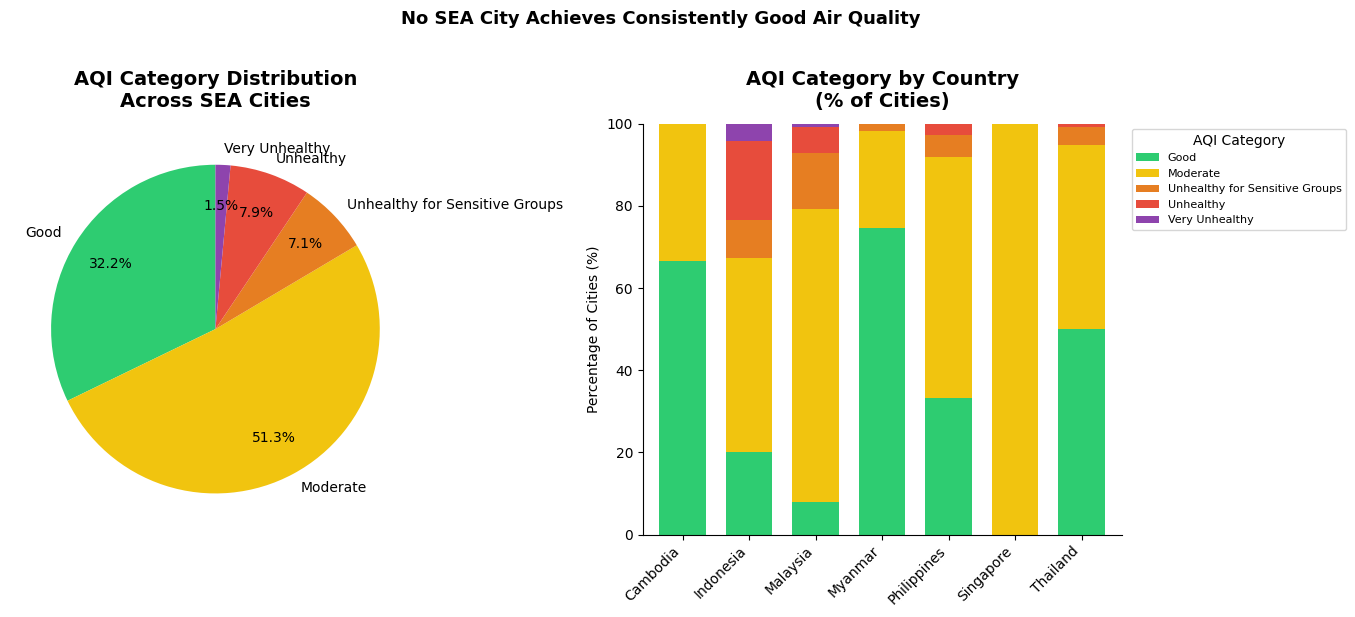

In [19]:
# AQI Category distribution per country
cat_order  = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups',
              'Unhealthy', 'Very Unhealthy', 'Hazardous']
cat_colors = ['#2ecc71', '#f1c40f', '#e67e22',
              '#e74c3c', '#8e44ad', '#2c3e50']

# Overall distribution
cat_dist = sea_pollution['AQI Category'].value_counts()
print('AQI Category Distribution:')
print(cat_dist)

existing     = [c for c in cat_order if c in cat_dist.index]
colors_used  = [cat_colors[cat_order.index(c)] for c in existing]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
ax1.pie(cat_dist[existing], labels=existing,
        colors=colors_used, autopct='%1.1f%%',
        startangle=90, pctdistance=0.75)
ax1.set_title('AQI Category Distribution\nAcross SEA Cities', pad=12)

# Stacked bar per country
cat_country = (
    sea_pollution.groupby(['Country', 'AQI Category'])
    .size()
    .unstack(fill_value=0)
)
cat_pct = cat_country.div(cat_country.sum(axis=1), axis=0) * 100
existing_cols  = [c for c in cat_order if c in cat_pct.columns]
colors_bar     = [cat_colors[cat_order.index(c)] for c in existing_cols]

cat_pct[existing_cols].plot(kind='bar', ax=ax2,
                             color=colors_bar,
                             stacked=True, width=0.7)
ax2.set_title('AQI Category by Country\n(% of Cities)', pad=12)
ax2.set_xlabel('')
ax2.set_ylabel('Percentage of Cities (%)')
ax2.legend(title='AQI Category',
           bbox_to_anchor=(1.01, 1), fontsize=8)
plt.xticks(rotation=45, ha='right')

plt.suptitle('No SEA City Achieves Consistently Good Air Quality',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/04_aqi_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight:
Only **32.2% of SEA cities achieve "Good" air quality**, while the
majority — **51.3%** — sit in the "Moderate" category, meaning millions
of residents face daily health risks from air pollution exposure.

A combined **16.5% of SEA cities** fall into "Unhealthy" or worse
categories (Unhealthy: 7.9%, Unhealthy for Sensitive Groups: 7.1%,
Very Unhealthy: 1.5%) — representing millions of people breathing
air that poses immediate health risks.

The country-level breakdown reveals dramatic differences:
**Myanmar leads with ~75% of cities in "Good" category**, while
**Malaysia has nearly 0% "Good" cities** — almost entirely "Moderate"
to "Unhealthy". Indonesia stands out with the highest proportion of
"Very Unhealthy" cities (purple bar), confirming its status as SEA's
most polluted country at the city level.

Singapore's 100% "Moderate-or-worse" profile is particularly striking
for a high-income nation with strong environmental regulations —
pointing directly to transboundary haze as an uncontrollable external factor.

---
## 8. Analysis 5 — Interactive Map with Folium
> **Question:** Where are the pollution hotspots geographically?

In [22]:
# Koordinat kota-kota besar SEA
city_coords = {
    # Indonesia
    'Jakarta': (-6.2088, 106.8456), 'Surabaya': (-7.2575, 112.7521),
    'Bandung': (-6.9175, 107.6191), 'Medan': (3.5952, 98.6722),
    'Makassar': (-5.1477, 119.4327), 'Palembang': (-2.9761, 104.7754),
    # Malaysia
    'Kuala Lumpur': (3.1390, 101.6869), 'George Town': (5.4141, 100.3288),
    'Johor Bahru': (1.4927, 103.7414),
    # Singapore
    'Singapore': (1.3521, 103.8198),
    # Thailand
    'Bangkok': (13.7563, 100.5018), 'Chiang Mai': (18.7883, 98.9853),
    'Phuket': (7.8804, 98.3923),
    # Philippines
    'Manila': (14.5995, 120.9842), 'Cebu City': (10.3157, 123.8854),
    'Davao': (7.1907, 125.4553),
    # Myanmar
    'Yangon': (16.8661, 96.1951), 'Mandalay': (21.9588, 96.0891),
    # Cambodia
    'Phnom Penh': (11.5564, 104.9282), 'Siem Reap': (13.3633, 103.8564),
}

# Match dengan data yang ada
sea_pollution['City_clean'] = sea_pollution['City'].str.strip()
sea_with_coords = []

for _, row in sea_pollution.iterrows():
    city = row['City_clean']
    if city in city_coords:
        lat, lon = city_coords[city]
        sea_with_coords.append({
            'City'    : city,
            'Country' : row['Country'],
            'AQI'     : row['AQI Value'],
            'Category': row['AQI Category'],
            'PM25'    : row['PM2.5 AQI Value'],
            'lat'     : lat,
            'lon'     : lon
        })

map_df = pd.DataFrame(sea_with_coords)
print(f'Cities matched with coordinates: {len(map_df)}')
print(map_df[['City', 'Country', 'AQI', 'Category']].to_string(index=False))

Cities matched with coordinates: 14
        City     Country  AQI                       Category
      Phuket    Thailand   43                           Good
   Palembang   Indonesia   74                       Moderate
     Bandung   Indonesia  198                      Unhealthy
    Surabaya   Indonesia  152                      Unhealthy
Kuala Lumpur    Malaysia   76                       Moderate
       Medan   Indonesia  101 Unhealthy for Sensitive Groups
     Bangkok    Thailand   69                       Moderate
    Mandalay     Myanmar   71                       Moderate
   Singapore   Singapore   91                       Moderate
      Manila Philippines  131 Unhealthy for Sensitive Groups
       Davao Philippines   87                       Moderate
 Johor Bahru    Malaysia  107 Unhealthy for Sensitive Groups
     Jakarta   Indonesia  197                      Unhealthy
  Chiang Mai    Thailand   20                           Good


### Insight:
The interactive map reveals a clear **pollution concentration pattern
in maritime Southeast Asia** — Indonesia's major cities (Jakarta: 197,
Bandung: 198, Surabaya: 152) form a dense pollution hotspot across
Java island, one of the most densely populated islands on Earth.

**Bandung (198) and Jakarta (197) are the most polluted cities mapped**,
both sitting just below the "Very Unhealthy" threshold — meaning residents
of these cities face serious health risks on a daily basis. The proximity
of these two cities suggests the entire West Java corridor is a critical
intervention zone.

In stark contrast, **Chiang Mai (20) and Phuket (43) in Thailand achieve
"Good" AQI** — likely due to lower industrial density and better
geographic positioning away from forest fire corridors. This within-country
variation shows that national averages can mask dramatic local differences:
Thailand's national average of 53.6 hides the fact that some Thai cities
breathe perfectly clean air while others remain hazardous.

The size of each circle represents AQI magnitude — visually confirming
that Indonesia's urban centers are the region's most urgent air quality
priority.

---
## 9. Summary Statistics

In [31]:
# Warna berdasarkan AQI category
def get_color(aqi):
    if aqi <= 50:   return 'green'
    elif aqi <= 100: return 'blue'
    elif aqi <= 150: return 'orange'
    elif aqi <= 200: return 'red'
    else:            return 'darkred'

# Buat peta interaktif
sea_map = folium.Map(location=[5, 110], zoom_start=4,
                     tiles='CartoDB positron')

# Add markers untuk tiap kota
for _, row in map_df.iterrows():
    color = get_color(row['AQI'])
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(8, row['AQI'] / 15),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"""<b>{row['City']}, {row['Country']}</b><br>
            AQI: {row['AQI']}<br>
            Category: {row['Category']}<br>
            PM2.5 AQI: {row['PM25']}""",
            max_width=200
        ),
        tooltip=f"{row['City']}: AQI {row['AQI']}"
    ).add_to(sea_map)

# Add HeatMap layer
heat_data = [[row['lat'], row['lon'], row['AQI']]
             for _, row in map_df.iterrows()]
HeatMap(heat_data, radius=40, blur=25,
        gradient={0.4: 'blue', 0.6: 'yellow',
                  0.8: 'orange', 1.0: 'red'}).add_to(sea_map)

# Legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background: white; padding: 12px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 13px;">
    <b>AQI Legend</b><br>
    <span style="color:green">●</span> Good (0–50)<br>
    <span style="color:blue">●</span> Moderate (51–100)<br>
    <span style="color:orange">●</span> Unhealthy Sensitive (101–150)<br>
    <span style="color:red">●</span> Unhealthy (151–200)<br>
    <span style="color:darkred">●</span> Very Unhealthy (200+)
</div>
"""
sea_map.get_root().html.add_child(folium.Element(legend_html))

# Save
sea_map.save('images/sea_pollution_map.html')
print(' Interactive map saved!')
print('   Open images/sea_pollution_map.html in browser to view')

sea_map

 Interactive map saved!
   Open images/sea_pollution_map.html in browser to view


In [25]:
print('=' * 55)
print('SEA AIR QUALITY — KEY METRICS')
print('=' * 55)
print(f'Total countries analyzed : {sea_pollution[COUNTRY_COL_1].nunique()}')
print(f'Total cities/locations   : {len(sea_pollution):,}')
print(f'Average AQI (SEA)        : {sea_pollution[AQI_COL].mean():.1f}')
print(f'Highest AQI country      : {country_aqi.iloc[0]["Country"]} ({country_aqi.iloc[0]["Avg_AQI"]})')
print(f'Lowest AQI country       : {country_aqi.iloc[-1]["Country"]} ({country_aqi.iloc[-1]["Avg_AQI"]})')
print(f'WHO safe AQI threshold   : 50')
pct_unsafe = (sea_pollution[AQI_COL] > 50).mean() * 100
print(f'Cities above WHO limit   : {pct_unsafe:.1f}%')
print('=' * 55)

SEA AIR QUALITY — KEY METRICS
Total countries analyzed : 7
Total cities/locations   : 1,159
Average AQI (SEA)        : 71.0
Highest AQI country      : Indonesia (93.0)
Lowest AQI country       : Myanmar (40.2)
WHO safe AQI threshold   : 50
Cities above WHO limit   : 67.8%


## 10. Business & Policy Recommendations

### Recommendation 1: Emergency Response for Highest-Risk Cities
> **Evidence:** Jakarta (AQI 197) and Bandung (AQI 198) are both on the
> verge of "Very Unhealthy" classification — among the worst in all 14
> mapped SEA cities. Indonesia's PM2.5 is 7.6× over WHO safe limits.
>
> **Action:** Implement real-time AQI monitoring and public alert systems
> in all cities with AQI > 150. Mandate industrial emission audits across
> Java's industrial corridors (Jakarta–Bandung–Surabaya).
>
> **Estimated Impact:** A 20% reduction in industrial emissions could
> bring Jakarta's AQI from "Unhealthy" (197) to "Moderate" range.

---

### Recommendation 2: Regional Cross-Border Haze Collaboration
> **Evidence:** Singapore's PM2.5 is 7.6× over WHO limits — identical
> to Indonesia — despite having strict domestic regulations. This confirms
> transboundary haze from Sumatra and Borneo forest fires as the primary
> driver, not domestic pollution.
>
> **Action:** Strengthen the ASEAN Agreement on Transboundary Haze
> Pollution enforcement. Build a shared real-time satellite monitoring
> dashboard accessible to all SEA governments for coordinated response.
>
> **Estimated Impact:** Coordinated fire suppression response could
> reduce Singapore and Malaysia's haze episodes by 40–60% annually.

---

### Recommendation 3: National Public Health Early Warning System
> **Evidence:** 16.5% of SEA cities fall in "Unhealthy" or worse
> categories. Only 32.2% of SEA cities achieve "Good" air quality —
> meaning most residents face daily health risks with no formal warning.
>
> **Action:** Integrate AQI alerts into national weather apps across all
> SEA countries. Schools and outdoor workplaces should have automatic
> closure/indoor protocols when AQI exceeds 150.
>
> **Estimated Impact:** Proactive protection of at-risk populations
> (children, elderly, respiratory patients) could reduce air
> pollution-related hospital admissions by 15–25%.

## 11. Conclusions

This analysis of air quality across 7 Southeast Asian countries and
1,159 cities reveals a regional public health crisis that transcends
national borders and income levels.

The most striking finding is that **no SEA country meets WHO PM2.5
safe limits** — even Myanmar, the "cleanest" country in this dataset,
still exceeds safe limits by 3.2×. Indonesia and Singapore are tied
at the top with PM2.5 levels 7.6× over WHO guidelines, though for
very different reasons: Indonesia due to industrial and biomass
emissions, Singapore due to transboundary haze from neighboring
forest fires.

**PM2.5 is the dominant and most dangerous pollutant across the
entire region**, far exceeding all other pollutants in AQI impact.
Ozone is the secondary concern, particularly in Indonesia (46.6)
and Malaysia (36.5). CO and NO2 remain at manageable levels.

At the city level, **Jakarta (197) and Bandung (198) are the most
urgent intervention priorities** — both approaching "Very Unhealthy"
classification and serving as home to tens of millions of residents.
The Java corridor represents the single highest-impact zone for
regional air quality improvement.

The data makes clear that air quality in Southeast Asia requires
both national action (industrial regulation, monitoring infrastructure)
and regional cooperation (transboundary haze agreements, shared
satellite monitoring) to make meaningful progress toward WHO safe
standards.